# IMC Prosperity 4 — Round 1 Data Inspection

**Products in scope:**  
- `INTARIAN_PEPPER_ROOT` — steady-value asset (analogous to tutorial EMERALDS)  
- `ASH_COATED_OSMIUM` — volatile asset that may follow a hidden pattern (analogous to tutorial TOMATOES)

**Datasets loaded:**  
| File | Description |
|---|---|
| `prices_round_1_day_0.csv` | Order-book snapshots — Round 1 Day 0 |
| `prices_round_1_day_-1.csv` | Order-book snapshots — Round 1 Day -1 |
| `prices_round_1_day_-2.csv` | Order-book snapshots — Round 1 Day -2 |
| `trades_round_1_day_-1.csv` | Market trades — Round 1 Day -1 |

**The delimiter problem:** CSVs use `;` instead of `,`. Pandas reads each row as a single string unless you pass `sep=';'`.  
This notebook documents the bug and the fix, then proceeds with clean data.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings('ignore')

# Plotting style: clean dark-ish quant aesthetic
plt.rcParams.update({
    'figure.facecolor'  : '#0e1117',
    'axes.facecolor'    : '#1a1d27',
    'axes.edgecolor'    : '#3a3f55',
    'axes.labelcolor'   : '#c9d1e0',
    'axes.titlecolor'   : '#ffffff',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 10,
    'xtick.color'       : '#8892a4',
    'ytick.color'       : '#8892a4',
    'xtick.labelsize'   : 8,
    'ytick.labelsize'   : 8,
    'grid.color'        : '#2a2f42',
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : '#1a1d27',
    'legend.edgecolor'  : '#3a3f55',
    'legend.fontsize'   : 8,
    'text.color'        : '#c9d1e0',
    'figure.titlesize'  : 15,
})

## 1. File Path Configuration

All four files live under your OneDrive Round 1 folder.  
Change `ROUND_1_DIR` if you move the data elsewhere.

In [2]:
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', '{:.2f}'.format)

# ---- CHANGE THIS PATH IF YOU MOVE YOUR DATA ----
ROUND_1_DIR = Path(
    r'C:\Users\Hassa\OneDrive - Loughborough University'
    r'\current\IMC Trading - Prosperity 4\Round 1'
)
# ------------------------------------------------

FILES = {
    'prices_d0'  : ROUND_1_DIR / 'prices_round_1_day_0.csv',
    'prices_dm1' : ROUND_1_DIR / 'prices_round_1_day_-1.csv',
    'prices_dm2' : ROUND_1_DIR / 'prices_round_1_day_-2.csv',
    'trades_dm1' : ROUND_1_DIR / 'trades_round_1_day_-1.csv',
}

missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    raise FileNotFoundError(
        'Cannot find the following files.\n'
        'Check that ROUND_1_DIR above is correct:\n'
        + '\n'.join(missing)
    )

print('All four files found:')
for key, path in FILES.items():
    size_kb = path.stat().st_size / 1024
    print(f'  {key:12s}  {path.name:40s}  ({size_kb:,.0f} KB)')

All four files found:
  prices_d0     prices_round_1_day_0.csv                  (1,444 KB)
  prices_dm1    prices_round_1_day_-1.csv                 (1,462 KB)
  prices_dm2    prices_round_1_day_-2.csv                 (1,459 KB)
  trades_dm1    trades_round_1_day_-1.csv                 (33 KB)


## 2. The Delimiter Bug (and the Fix)

The CSVs use `;` as a separator. Pandas defaults to `,`, collapsing all 17 columns into one.

In [3]:
# Read with the DEFAULT separator (comma) — shows the bug
broken = pd.read_csv(FILES['prices_dm1'])
print(f'Shape with default comma separator: {broken.shape}  <- WRONG: all 17 fields crammed into 1 column')
print(f'Column name: {broken.columns.tolist()}')
print()
broken.head(3)

Shape with default comma separator: (20000, 1)  <- WRONG: all 17 fields crammed into 1 column
Column name: ['day;timestamp;product;bid_price_1;bid_volume_1;bid_price_2;bid_volume_2;bid_price_3;bid_volume_3;ask_price_1;ask_volume_1;ask_price_2;ask_volume_2;ask_price_3;ask_volume_3;mid_price;profit_and_loss']



,day;timestamp;product;bid_price_1;bid_volume_1;bid_price_2;bid_volume_2;bid_price_3;bid_volume_3;ask_price_1;ask_volume_1;ask_price_2;ask_volume_2;ask_price_3;ask_volume_3;mid_price;profit_and_loss
0,-1;0;INTARIAN_PEPPER_ROOT;10991;15;;;;;11006;1...
1,-1;0;ASH_COATED_OSMIUM;;;;;;;10003;29;;;;;1000...
2,-1;100;ASH_COATED_OSMIUM;9984;11;;;;;10000;11;...


In [4]:
# Read with the CORRECT separator — 17 clean columns
fixed = pd.read_csv(FILES['prices_dm1'], sep=';')
print(f'Shape with sep=";": {fixed.shape}  <- CORRECT: 17 proper columns')
print(f'Columns: {fixed.columns.tolist()}')
print()
fixed.head(4)

Shape with sep=";": (20000, 17)  <- CORRECT: 17 proper columns
Columns: ['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']



,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10991.00,15.00,NaN,NaN,NaN,NaN,11006.00,10.00,11009.00,15.00,NaN,NaN,10998.50,0.00
1,-1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10003.00,29.00,NaN,NaN,NaN,NaN,10003.00,0.00
2,-1,100,ASH_COATED_OSMIUM,9984.00,11.00,NaN,NaN,NaN,NaN,10000.00,11.00,10003.00,22.00,NaN,NaN,9992.00,0.00
3,-1,100,INTARIAN_PEPPER_ROOT,10994.00,9.00,10991.00,21.00,NaN,NaN,11006.00,9.00,11009.00,21.00,NaN,NaN,11000.00,0.00


## 3. Loader Functions

In [5]:
def load_prices(path: Path) -> pd.DataFrame:
    """
    Load a Prosperity prices CSV.
    - Splits on semicolons (the actual delimiter)
    - Casts every numeric column; empty level-2/3 cells become NaN
    - Adds three derived columns: spread, total_bid_depth, total_ask_depth
    - Adds a WallMid column: midpoint between the largest bid wall and largest ask wall
      (Frankfurt Hedgehogs technique for noise-robust fair value)
    """
    df = pd.read_csv(path, sep=';')

    numeric_cols = [
        'timestamp',
        'bid_price_1', 'bid_volume_1',
        'bid_price_2', 'bid_volume_2',
        'bid_price_3', 'bid_volume_3',
        'ask_price_1', 'ask_volume_1',
        'ask_price_2', 'ask_volume_2',
        'ask_price_3', 'ask_volume_3',
        'mid_price', 'profit_and_loss',
    ]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    df['day'] = df['day'].astype(int)

    # Derived columns useful for strategy development
    df['spread']          = df['ask_price_1'] - df['bid_price_1']
    df['total_bid_depth'] = df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].sum(axis=1, min_count=1)
    df['total_ask_depth'] = df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].sum(axis=1, min_count=1)

    # Order book imbalance: positive = more bid pressure, negative = more ask pressure
    df['book_imbalance'] = (
        (df['total_bid_depth'] - df['total_ask_depth']) /
        (df['total_bid_depth'] + df['total_ask_depth'])
    )

    # Rolling 50-tick EMA of mid price per product (computed after loading all data)
    return df


def load_trades(path: Path, day: int) -> pd.DataFrame:
    """
    Load a Prosperity trades CSV.
    - Splits on semicolons
    - Adds the simulation day as a column (absent in the raw file)
    - Adds notional = price * quantity
    """
    df = pd.read_csv(path, sep=';')
    df['day']      = day
    df['price']    = pd.to_numeric(df['price'],    errors='coerce')
    df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
    df['notional'] = df['price'] * df['quantity']
    return df

In [6]:
# Load all four files
prices_d0  = load_prices(FILES['prices_d0'])
prices_dm1 = load_prices(FILES['prices_dm1'])
prices_dm2 = load_prices(FILES['prices_dm2'])
trades_dm1 = load_trades(FILES['trades_dm1'], day=-1)

# Combined views across all three price days
prices_all = pd.concat([prices_dm2, prices_dm1, prices_d0], ignore_index=True)

print(f'prices_d0   ->  {prices_d0.shape[0]:>6,} rows  x  {prices_d0.shape[1]} columns  (Day  0)')
print(f'prices_dm1  ->  {prices_dm1.shape[0]:>6,} rows  x  {prices_dm1.shape[1]} columns  (Day -1)')
print(f'prices_dm2  ->  {prices_dm2.shape[0]:>6,} rows  x  {prices_dm2.shape[1]} columns  (Day -2)')
print(f'prices_all  ->  {prices_all.shape[0]:>6,} rows  x  {prices_all.shape[1]} columns  (all days combined)')
print(f'trades_dm1  ->  {trades_dm1.shape[0]:>6,} rows  x  {trades_dm1.shape[1]} columns  (Day -1 trades)')
print()
print('Products detected in prices data:')
print(prices_all['product'].value_counts().to_string())

prices_d0   ->  20,000 rows  x  21 columns  (Day  0)
prices_dm1  ->  20,000 rows  x  21 columns  (Day -1)
prices_dm2  ->  20,000 rows  x  21 columns  (Day -2)
prices_all  ->  60,000 rows  x  21 columns  (all days combined)
trades_dm1  ->     760 rows  x  9 columns  (Day -1 trades)

Products detected in prices data:
product
INTARIAN_PEPPER_ROOT    30000
ASH_COATED_OSMIUM       30000


## 4. Column Reference Guide

In [7]:
# Detect the actual product names from the data
detected_products = sorted(prices_all['product'].unique().tolist())
product_str = ' or '.join(detected_products)

col_descriptions = {
    'day'            : 'Simulation day (0, -1, or -2)',
    'timestamp'      : 'Tick number (0 to 999,900 in steps of 100ms)',
    'product'        : product_str,
    'bid_price_1'    : 'Best (highest) bid price in the order book',
    'bid_volume_1'   : 'Units available at best bid',
    'bid_price_2'    : 'Second-best bid price (next level down)',
    'bid_volume_2'   : 'Units at second bid level',
    'bid_price_3'    : 'Third bid level — often empty (NaN)',
    'bid_volume_3'   : 'Units at third bid level',
    'ask_price_1'    : 'Best (lowest) ask price in the order book',
    'ask_volume_1'   : 'Units available at best ask',
    'ask_price_2'    : 'Second-best ask price',
    'ask_volume_2'   : 'Units at second ask level',
    'ask_price_3'    : 'Third ask level — often empty (NaN)',
    'ask_volume_3'   : 'Units at third ask level',
    'mid_price'      : '(bid_price_1 + ask_price_1) / 2',
    'profit_and_loss': 'Simulator bot cumulative PnL',
    'spread'         : 'DERIVED: ask_price_1 - bid_price_1',
    'total_bid_depth': 'DERIVED: sum of bid volumes across all 3 levels',
    'total_ask_depth': 'DERIVED: sum of ask volumes across all 3 levels',
    'book_imbalance' : 'DERIVED: (bid_depth - ask_depth) / (bid_depth + ask_depth)',
}

ref = pd.DataFrame({
    'dtype'      : prices_all.dtypes.astype(str),
    'non_null'   : prices_all.notna().sum(),
    'null_pct'   : (prices_all.isna().mean() * 100).round(1).astype(str) + '%',
    'description': pd.Series(col_descriptions),
})

print('PRICES column reference')
display(ref)

PRICES column reference


,dtype,non_null,null_pct,description
day,int32,60000,0.0%,"Simulation day (0, -1, or -2)"
timestamp,int64,60000,0.0%,"Tick number (0 to 999,900 in steps of 100ms)"
product,object,60000,0.0%,ASH_COATED_OSMIUM or INTARIAN_PEPPER_ROOT
bid_price_1,float64,57580,4.0%,Best (highest) bid price in the order book
bid_volume_1,float64,57580,4.0%,Units available at best bid
bid_price_2,float64,39009,35.0%,Second-best bid price (next level down)
bid_volume_2,float64,39009,35.0%,Units at second bid level
bid_price_3,float64,1224,98.0%,Third bid level — often empty (NaN)
bid_volume_3,float64,1224,98.0%,Units at third bid level
ask_price_1,float64,57649,3.9%,Best (lowest) ask price in the order book


In [8]:
# Trades column reference
trade_col_descriptions = {
    'timestamp': 'Tick when the trade executed',
    'buyer'    : 'Buyer ID — named bots appear in later rounds; may be empty here',
    'seller'   : 'Seller ID — empty if bot anonymised',
    'symbol'   : product_str,
    'currency' : 'XIRECS',
    'price'    : 'Execution price (equals bid_price_1 or ask_price_1 at that tick)',
    'quantity' : 'Units traded',
    'day'      : 'DERIVED: simulation day',
    'notional' : 'DERIVED: price x quantity',
}

tref = pd.DataFrame({
    'dtype'      : trades_dm1.dtypes.astype(str),
    'non_null'   : trades_dm1.notna().sum(),
    'null_pct'   : (trades_dm1.isna().mean() * 100).round(1).astype(str) + '%',
    'description': pd.Series(trade_col_descriptions),
})

print('TRADES column reference')
display(tref)

TRADES column reference


,dtype,non_null,null_pct,description
timestamp,int64,760,0.0%,Tick when the trade executed
buyer,float64,0,100.0%,Buyer ID — named bots appear in later rounds; ...
seller,float64,0,100.0%,Seller ID — empty if bot anonymised
symbol,object,760,0.0%,ASH_COATED_OSMIUM or INTARIAN_PEPPER_ROOT
currency,object,760,0.0%,XIRECS
price,float64,760,0.0%,Execution price (equals bid_price_1 or ask_pri...
quantity,int64,760,0.0%,Units traded
day,int64,760,0.0%,DERIVED: simulation day
notional,float64,760,0.0%,DERIVED: price x quantity


## 5. First-Look: Head / Tail by Product

In [9]:
# Helper: pretty-print the head of any product slice
def show_head(df_source, product_name, day_label, n=8):
    subset = df_source[
        (df_source['product'] == product_name) &
        (df_source['day'] == day_label)
    ]
    print(f'{product_name}  (Day {day_label}) -- first {n} rows')
    display(subset.head(n))
    print()

# Determine which products exist in the data
PRODUCTS = sorted(prices_all['product'].unique())
DAYS     = sorted(prices_all['day'].unique())

print(f'Products: {PRODUCTS}')
print(f'Days:     {DAYS}')
print()

for product in PRODUCTS:
    show_head(prices_all, product, DAYS[-1])  # Most recent day

Products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
Days:     [-2, -1, 0]

ASH_COATED_OSMIUM  (Day 0) -- first 8 rows


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,total_bid_depth,total_ask_depth,book_imbalance
40000,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.00,30.00,NaN,NaN,NaN,NaN,10013.00,0.00,NaN,NaN,30.00,NaN
40003,0,100,ASH_COATED_OSMIUM,9995.00,13.00,NaN,NaN,NaN,NaN,10011.00,13.00,10013.00,30.00,NaN,NaN,10003.00,0.00,16.00,13.00,43.00,-0.54
40005,0,200,ASH_COATED_OSMIUM,9994.00,13.00,9992.00,21.00,NaN,NaN,10013.00,21.00,NaN,NaN,NaN,NaN,10003.50,0.00,19.00,34.00,21.00,0.24
40006,0,300,ASH_COATED_OSMIUM,9994.00,11.00,9992.00,23.00,NaN,NaN,10010.00,11.00,10013.00,23.00,NaN,NaN,10002.00,0.00,16.00,34.00,34.00,0.00
40008,0,400,ASH_COATED_OSMIUM,9994.00,13.00,9991.00,23.00,NaN,NaN,10010.00,13.00,10012.00,23.00,NaN,NaN,10002.00,0.00,16.00,36.00,36.00,0.00
40011,0,500,ASH_COATED_OSMIUM,9994.00,12.00,9991.00,22.00,NaN,NaN,10010.00,12.00,10012.00,22.00,NaN,NaN,10002.00,0.00,16.00,34.00,34.00,0.00
40013,0,600,ASH_COATED_OSMIUM,9991.00,24.00,NaN,NaN,NaN,NaN,10010.00,12.00,NaN,NaN,NaN,NaN,10000.50,0.00,19.00,24.00,12.00,0.33
40014,0,700,ASH_COATED_OSMIUM,9991.00,27.00,NaN,NaN,NaN,NaN,10010.00,10.00,NaN,NaN,NaN,NaN,10000.50,0.00,19.00,27.00,10.00,0.46



INTARIAN_PEPPER_ROOT  (Day 0) -- first 8 rows


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,total_bid_depth,total_ask_depth,book_imbalance
40001,0,0,INTARIAN_PEPPER_ROOT,11991.00,19.00,NaN,NaN,NaN,NaN,12006.00,10.00,12009.00,19.00,NaN,NaN,11998.50,0.00,15.00,19.00,29.00,-0.21
40002,0,100,INTARIAN_PEPPER_ROOT,11994.00,9.00,11991.00,23.00,NaN,NaN,12007.00,9.00,12010.00,23.00,NaN,NaN,12000.50,0.00,13.00,32.00,32.00,0.00
40004,0,200,INTARIAN_PEPPER_ROOT,11991.00,20.00,NaN,NaN,NaN,NaN,12007.00,11.00,12010.00,20.00,NaN,NaN,11999.00,0.00,16.00,20.00,31.00,-0.22
40007,0,300,INTARIAN_PEPPER_ROOT,11994.00,10.00,11991.00,24.00,NaN,NaN,12007.00,10.00,NaN,NaN,NaN,NaN,12000.50,0.00,13.00,34.00,10.00,0.55
40009,0,400,INTARIAN_PEPPER_ROOT,11994.00,12.00,11991.00,25.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11994.00,0.00,NaN,37.00,NaN,NaN
40010,0,500,INTARIAN_PEPPER_ROOT,11994.00,11.00,11991.00,25.00,NaN,NaN,12007.00,11.00,12010.00,25.00,NaN,NaN,12000.50,0.00,13.00,36.00,36.00,0.00
40012,0,600,INTARIAN_PEPPER_ROOT,11991.00,17.00,NaN,NaN,NaN,NaN,12007.00,9.00,12010.00,17.00,NaN,NaN,11999.00,0.00,16.00,17.00,26.00,-0.21
40015,0,700,INTARIAN_PEPPER_ROOT,11994.00,11.00,11991.00,24.00,NaN,NaN,12007.00,11.00,12010.00,24.00,NaN,NaN,12000.50,0.00,13.00,35.00,35.00,0.00


In [10]:
# Trades head/tail
for product in PRODUCTS:
    subset = trades_dm1[trades_dm1['symbol'] == product].reset_index(drop=True)
    print(f'TRADES -- {product}  (Day -1)  :  {len(subset)} trades total')
    display(subset.head(8))
    print()

TRADES -- ASH_COATED_OSMIUM  (Day -1)  :  425 trades total


,timestamp,buyer,seller,symbol,currency,price,quantity,day,notional
0,2800,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9985.00,10,-1,99850.00
1,5200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10004.00,6,-1,60024.00
2,5200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9986.00,9,-1,89874.00
3,7500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10003.00,6,-1,60018.00
4,9000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10004.00,10,-1,100040.00
5,13000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10005.00,2,-1,20010.00
6,14600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10007.00,5,-1,50035.00
7,14900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10007.00,5,-1,50035.00



TRADES -- INTARIAN_PEPPER_ROOT  (Day -1)  :  335 trades total


,timestamp,buyer,seller,symbol,currency,price,quantity,day,notional
0,3000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10999.00,8,-1,87992.00
1,4200,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10995.00,4,-1,43980.00
2,6300,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11000.00,4,-1,44000.00
3,17900,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11012.00,6,-1,66072.00
4,19700,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11011.00,7,-1,77077.00
5,24100,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11030.00,5,-1,55150.00
6,25800,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11029.00,3,-1,33087.00
7,28200,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11034.00,6,-1,66204.00


## 6. Summary Statistics by Product

In [11]:
key_price_cols = ['mid_price', 'spread', 'total_bid_depth', 'total_ask_depth', 'book_imbalance']

for product in PRODUCTS:
    print(f'PRICES -- {product}  (all days combined)')
    subset = prices_all[prices_all['product'] == product][key_price_cols]
    display(subset.describe().T.round(3))
    print()

PRICES -- ASH_COATED_OSMIUM  (all days combined)


,count,mean,std,min,25%,50%,75%,max
mid_price,30000.00,9983.87,403.87,0.00,9997.00,10000.50,10003.50,10023.00
spread,27644.00,16.18,2.57,5.00,16.00,16.00,18.00,22.00
total_bid_depth,28796.00,31.37,10.26,2.00,25.00,35.00,39.00,55.00
total_ask_depth,28799.00,31.42,10.22,2.00,25.00,35.00,39.00,54.00
book_imbalance,27644.00,-0.00,0.27,-0.91,-0.14,0.00,0.12,0.92



PRICES -- INTARIAN_PEPPER_ROOT  (all days combined)


,count,mean,std,min,25%,50%,75%,max
mid_price,30000.00,11479.19,993.18,0.00,10745.50,11497.50,12248.50,13007.00
spread,27688.00,13.05,2.63,2.00,12.00,13.00,14.00,21.00
total_bid_depth,28784.00,25.16,8.35,3.00,20.00,27.00,32.00,47.00
total_ask_depth,28850.00,25.19,8.34,3.00,20.00,27.00,32.00,47.00
book_imbalance,27688.00,-0.00,0.27,-0.83,-0.14,0.00,0.12,0.82


In [12]:
key_trade_cols = ['price', 'quantity', 'notional']

for product in PRODUCTS:
    print(f'TRADES -- {product}  (Day -1)')
    subset = trades_dm1[trades_dm1['symbol'] == product][key_trade_cols]
    display(subset.describe().T.round(3))
    print()

TRADES -- ASH_COATED_OSMIUM  (Day -1)


,count,mean,std,min,25%,50%,75%,max
price,425.00,10000.77,9.10,9982.00,9993.00,10001.00,10009.00,10019.00
quantity,425.00,5.24,2.28,2.00,3.00,5.00,6.00,10.00
notional,425.00,52357.37,22761.25,19964.00,30039.00,50035.00,60072.00,100190.00



TRADES -- INTARIAN_PEPPER_ROOT  (Day -1)


,count,mean,std,min,25%,50%,75%,max
price,335.00,11503.09,285.80,10995.00,11263.50,11511.00,11749.50,12005.00
quantity,335.00,5.25,1.48,3.00,4.00,5.00,6.00,8.00
notional,335.00,60297.41,16982.79,33087.00,45974.00,59345.00,71793.00,94952.00


In [13]:
# Spread value counts -- the most important microstructure fingerprint
for product in PRODUCTS:
    print(f'{product}: spread value counts (all days)')
    counts = (
        prices_all[prices_all['product'] == product]['spread']
        .value_counts()
        .sort_index()
        .rename('ticks')
        .to_frame()
    )
    counts['pct'] = (counts['ticks'] / counts['ticks'].sum() * 100).round(1).astype(str) + '%'
    display(counts)
    print()

ASH_COATED_OSMIUM: spread value counts (all days)


,ticks,pct
spread,,
5.00,154,0.6%
6.00,328,1.2%
7.00,164,0.6%
8.00,62,0.2%
9.00,375,1.4%
10.00,639,2.3%
11.00,323,1.2%
12.00,109,0.4%
13.00,156,0.6%



INTARIAN_PEPPER_ROOT: spread value counts (all days)


,ticks,pct
spread,,
2.00,282,1.0%
3.00,373,1.3%
4.00,138,0.5%
5.00,49,0.2%
6.00,57,0.2%
7.00,66,0.2%
8.00,141,0.5%
9.00,128,0.5%
10.00,67,0.2%


---
## 7. TIME-SERIES VISUALISATIONS

Four fully-annotated charts, one per dataset.

---
### Chart 1: Prices Day -2 — Mid Price + Spread + Depth

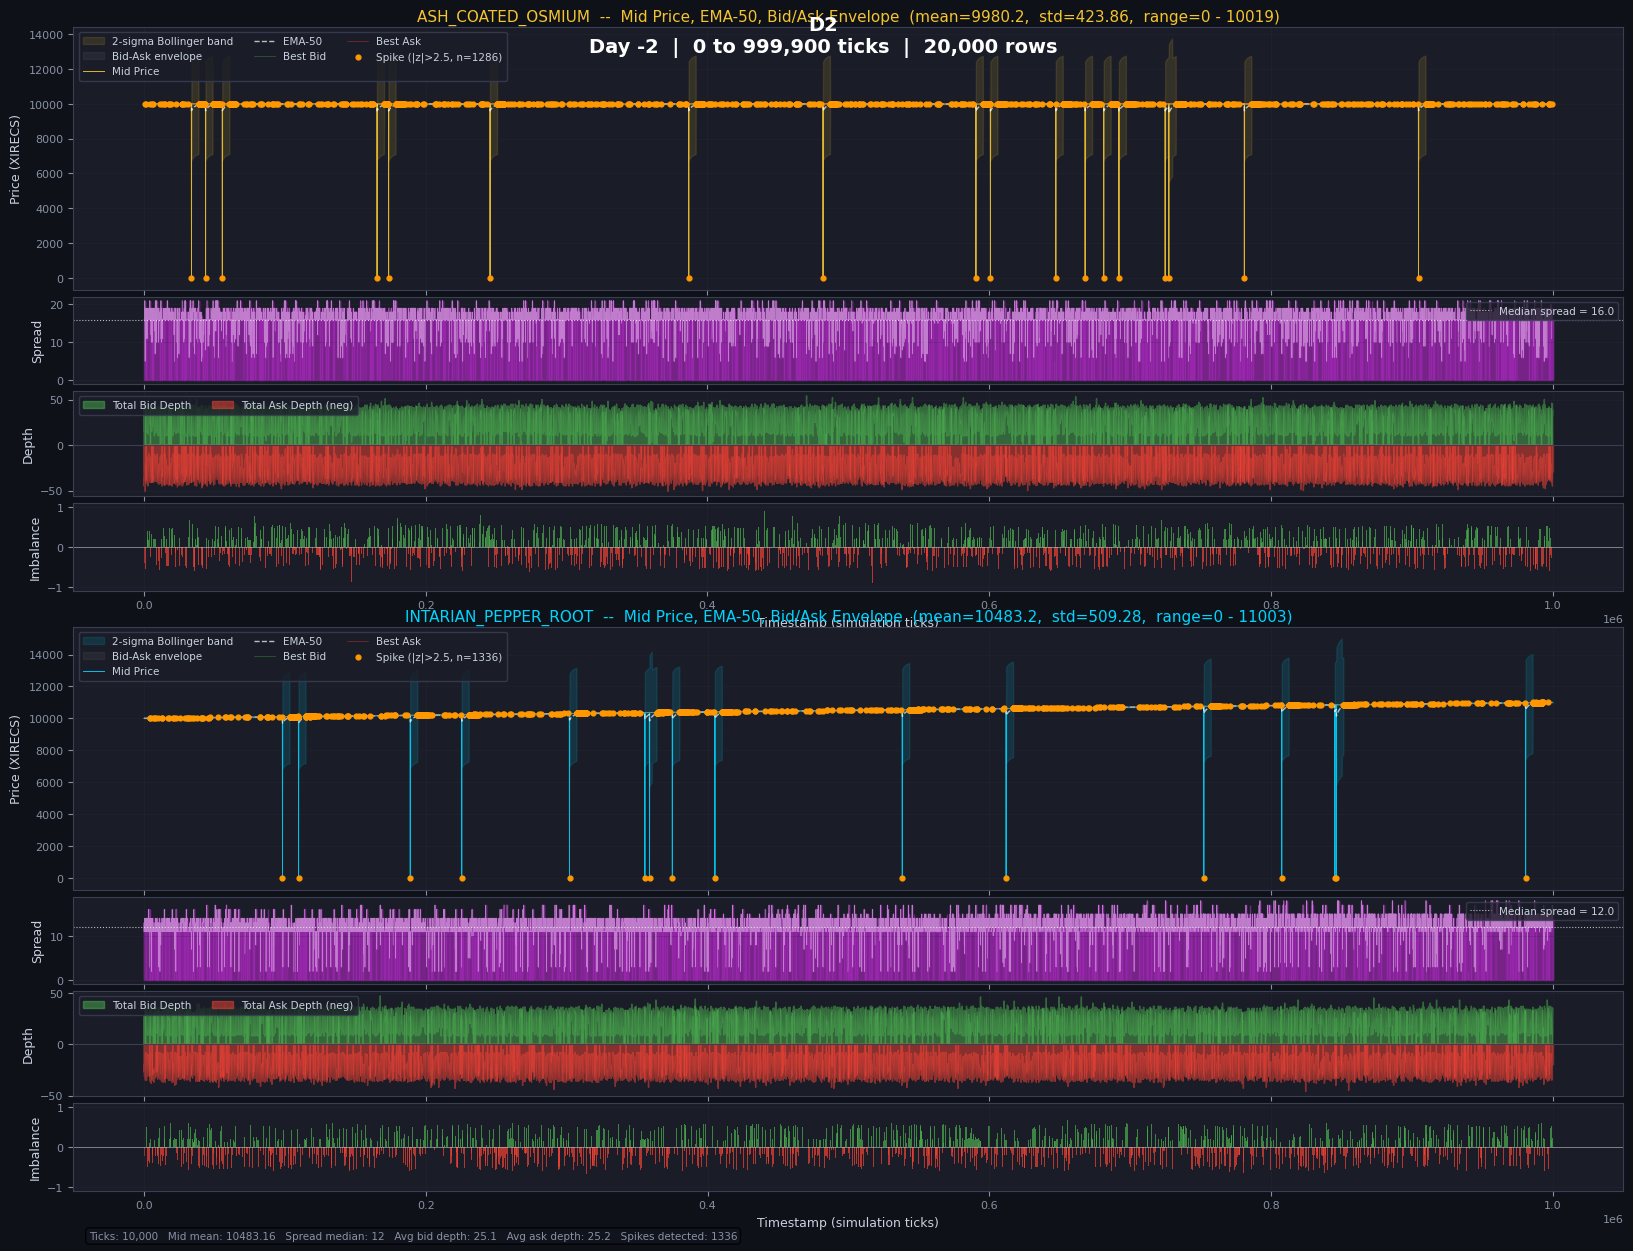

In [16]:
def plot_prices_overview(df, day_label, fig_title):
    """
    Four-panel plot for one prices day:
    Row 1: Mid price time series with EMA, bid/ask envelope
    Row 2: Bid-ask spread over time
    Row 3: Total order-book depth (bid vs ask)
    Row 4: Book imbalance heatmap
    """
    products = sorted(df['product'].unique())
    n_products = len(products)

    fig = plt.figure(figsize=(20, 6 * n_products), facecolor='#0e1117')
    fig.suptitle(
        f'{fig_title}\n'
        f'Day {day_label}  |  '
        f'{df["timestamp"].min():,} to {df["timestamp"].max():,} ticks  |  '
        f'{len(df):,} rows',
        fontsize=14, fontweight='bold', color='white', y=1.01
    )

    # Color palette: amber for INTARIAN_PEPPER_ROOT, cyan for ASH_COATED_OSMIUM
    palette = {
        products[0]: '#f4c430',
        products[1]: '#00d4ff',
    } if n_products >= 2 else {products[0]: '#f4c430'}

    for p_idx, product in enumerate(products):
        pdf = df[df['product'] == product].copy().sort_values('timestamp')
        ts  = pdf['timestamp']
        color = palette.get(product, '#f4c430')

        # EMA-50 of mid price
        pdf['ema50'] = pdf['mid_price'].ewm(span=50, adjust=False).mean()
        # Rolling std for Bollinger-like bands
        pdf['rolling_std'] = pdf['mid_price'].rolling(50, min_periods=5).std()
        pdf['upper_band']  = pdf['ema50'] + 2 * pdf['rolling_std']
        pdf['lower_band']  = pdf['ema50'] - 2 * pdf['rolling_std']

        # Spike detection (|z-score| > 2.5)
        z = (pdf['mid_price'] - pdf['ema50']) / (pdf['rolling_std'] + 1e-9)
        spike_mask = z.abs() > 2.5

        gs = gridspec.GridSpec(
            4, 1, figure=fig,
            top=1.0 - p_idx * (1.0 / n_products),
            bottom=1.0 - (p_idx + 1) * (1.0 / n_products) + 0.03,
            hspace=0.05,
            height_ratios=[3, 1, 1.2, 1]
        )

        # ---- Panel 1: Mid Price ----
        ax1 = fig.add_subplot(gs[0])
        ax1.fill_between(ts, pdf['lower_band'], pdf['upper_band'],
                         alpha=0.12, color=color, label='2-sigma Bollinger band')
        ax1.fill_between(ts, pdf['bid_price_1'], pdf['ask_price_1'],
                         alpha=0.08, color='#aaaaaa', label='Bid-Ask envelope')
        ax1.plot(ts, pdf['mid_price'], color=color, linewidth=0.7,
                 alpha=0.9, label='Mid Price')
        ax1.plot(ts, pdf['ema50'],     color='white', linewidth=1.0,
                 linestyle='--', alpha=0.7, label='EMA-50')
        ax1.plot(ts, pdf['bid_price_1'], color='#4caf50', linewidth=0.4,
                 alpha=0.6, label='Best Bid')
        ax1.plot(ts, pdf['ask_price_1'], color='#f44336', linewidth=0.4,
                 alpha=0.6, label='Best Ask')

        # Annotate spike moments
        spike_ts  = ts[spike_mask]
        spike_val = pdf['mid_price'][spike_mask]
        ax1.scatter(spike_ts, spike_val, color='#ff9800', s=12, zorder=5,
                    label=f'Spike (|z|>2.5, n={spike_mask.sum()})')

        ax1.set_title(
            f'{product}  --  Mid Price, EMA-50, Bid/Ask Envelope  '
            f'(mean={pdf["mid_price"].mean():.1f},  '
            f'std={pdf["mid_price"].std():.2f},  '
            f'range={pdf["mid_price"].min():.0f} - {pdf["mid_price"].max():.0f})',
            fontsize=11, color=color, pad=4
        )
        ax1.set_ylabel('Price (XIRECS)', fontsize=9)
        ax1.legend(loc='upper left', ncol=3, fontsize=7.5)
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(labelbottom=False)

        # ---- Panel 2: Spread ----
        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2.fill_between(ts, pdf['spread'],
                         step='mid', alpha=0.7, color='#9c27b0')
        ax2.plot(ts, pdf['spread'], color='#ce93d8', linewidth=0.5, alpha=0.8)
        ax2.axhline(pdf['spread'].median(), color='white', linewidth=0.8,
                    linestyle=':', alpha=0.7,
                    label=f'Median spread = {pdf["spread"].median():.1f}')
        ax2.set_ylabel('Spread', fontsize=9)
        ax2.legend(loc='upper right', fontsize=7.5)
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(labelbottom=False)

        # ---- Panel 3: Order Book Depth ----
        ax3 = fig.add_subplot(gs[2], sharex=ax1)
        ax3.fill_between(ts, pdf['total_bid_depth'],
                         alpha=0.5, color='#4caf50', label='Total Bid Depth')
        ax3.fill_between(ts, -pdf['total_ask_depth'],
                         alpha=0.5, color='#f44336', label='Total Ask Depth (neg)')
        ax3.axhline(0, color='#3a3f55', linewidth=0.8)
        ax3.set_ylabel('Depth', fontsize=9)
        ax3.legend(loc='upper left', ncol=2, fontsize=7.5)
        ax3.grid(True, alpha=0.3)
        ax3.tick_params(labelbottom=False)

        # ---- Panel 4: Book Imbalance ----
        ax4 = fig.add_subplot(gs[3], sharex=ax1)
        imb = pdf['book_imbalance'].clip(-1, 1)
        # Color bars by sign
        colors_imb = ['#4caf50' if v >= 0 else '#f44336' for v in imb]
        ax4.bar(ts, imb, color=colors_imb, width=200, alpha=0.7)
        ax4.axhline(0, color='white', linewidth=0.6, alpha=0.5)
        ax4.set_ylabel('Imbalance', fontsize=9)
        ax4.set_xlabel('Timestamp (simulation ticks)', fontsize=9)
        ax4.set_ylim(-1.1, 1.1)
        ax4.grid(True, alpha=0.3)

        # Shared annotation box
        stats_text = (
            f'Ticks: {len(pdf):,}   '
            f'Mid mean: {pdf["mid_price"].mean():.2f}   '
            f'Spread median: {pdf["spread"].median():.0f}   '
            f'Avg bid depth: {pdf["total_bid_depth"].mean():.1f}   '
            f'Avg ask depth: {pdf["total_ask_depth"].mean():.1f}   '
            f'Spikes detected: {spike_mask.sum()}'
        )
        ax4.annotate(
            stats_text,
            xy=(0.01, -0.55), xycoords='axes fraction',
            fontsize=7.5, color='#8892a4',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#12151e', alpha=0.8)
        )

    plt.tight_layout()
    plt.show()


# Chart 1: Day -2
plot_prices_overview(prices_dm2, day_label=-2,
                     fig_title='D2')

---
### Chart 2: Prices Day -1

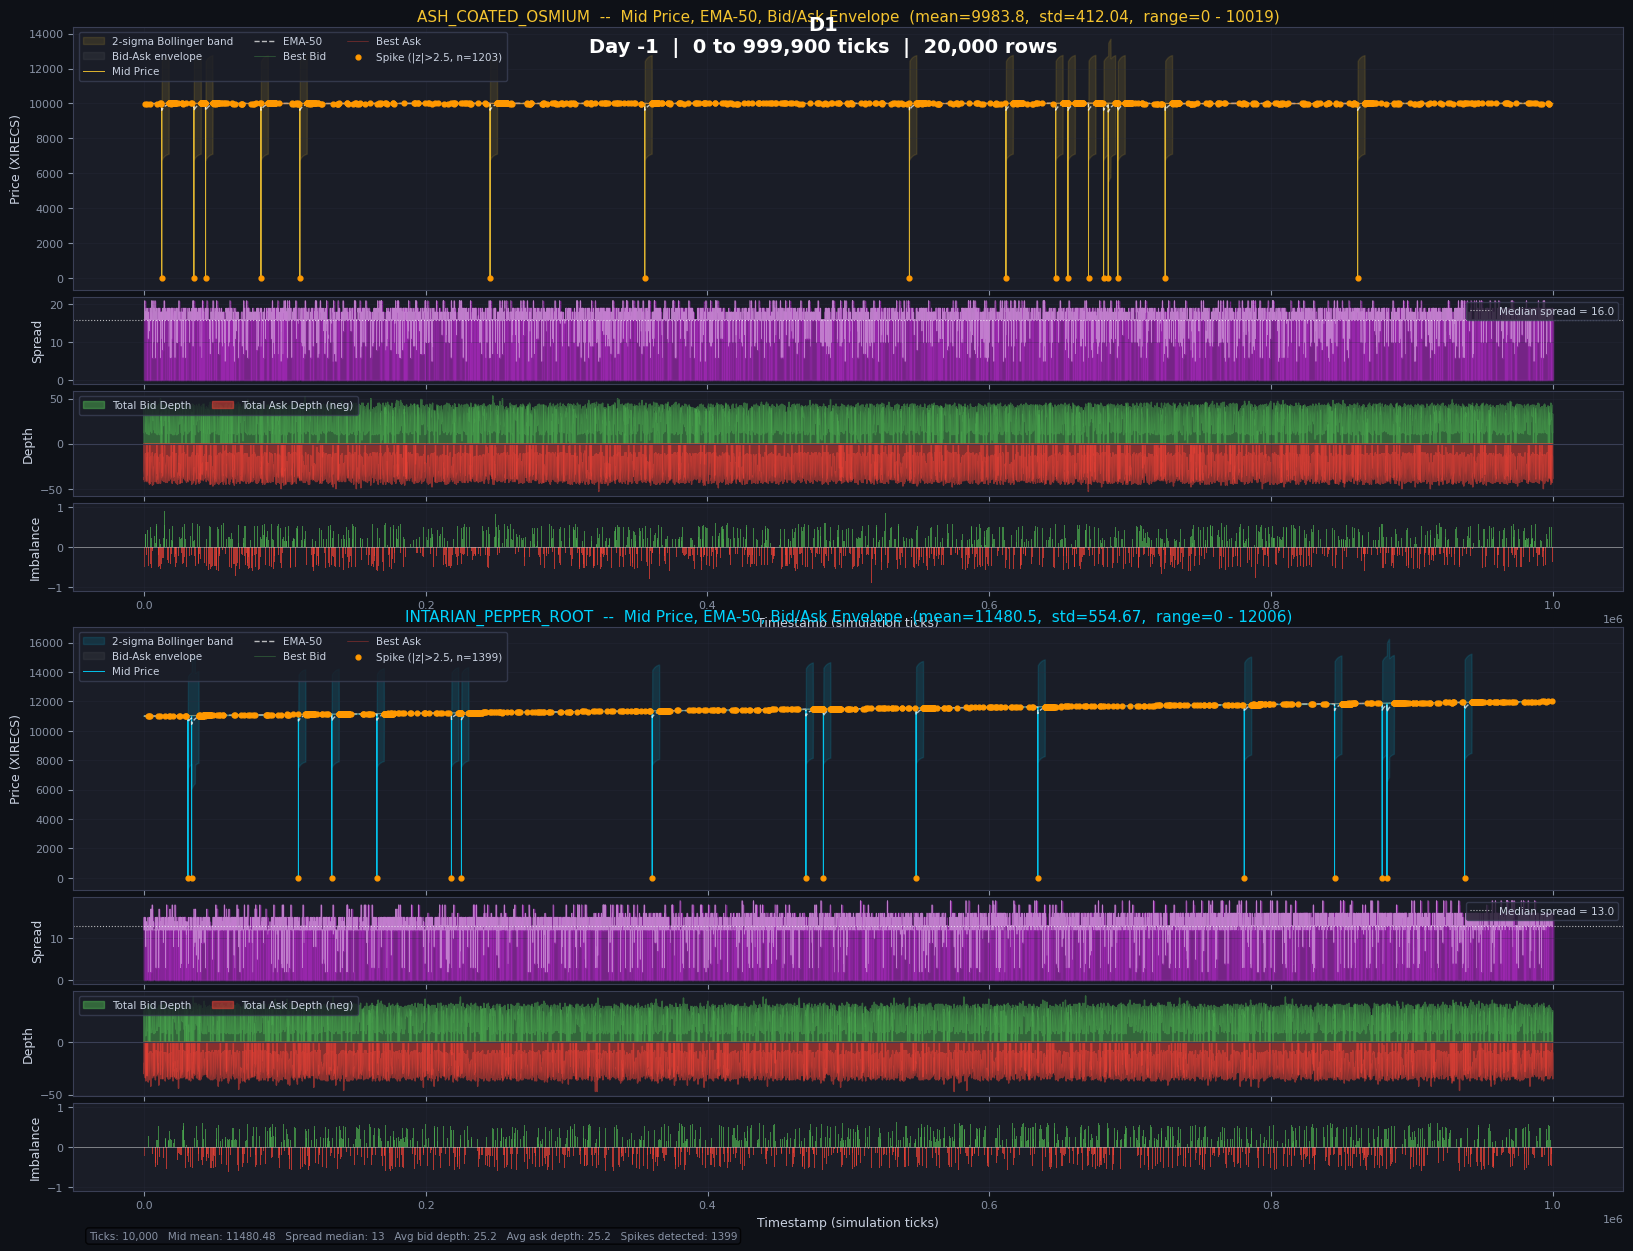

In [17]:
plot_prices_overview(prices_dm1, day_label=-1,
                     fig_title='D1')

---
### Chart 3: Prices Day 0

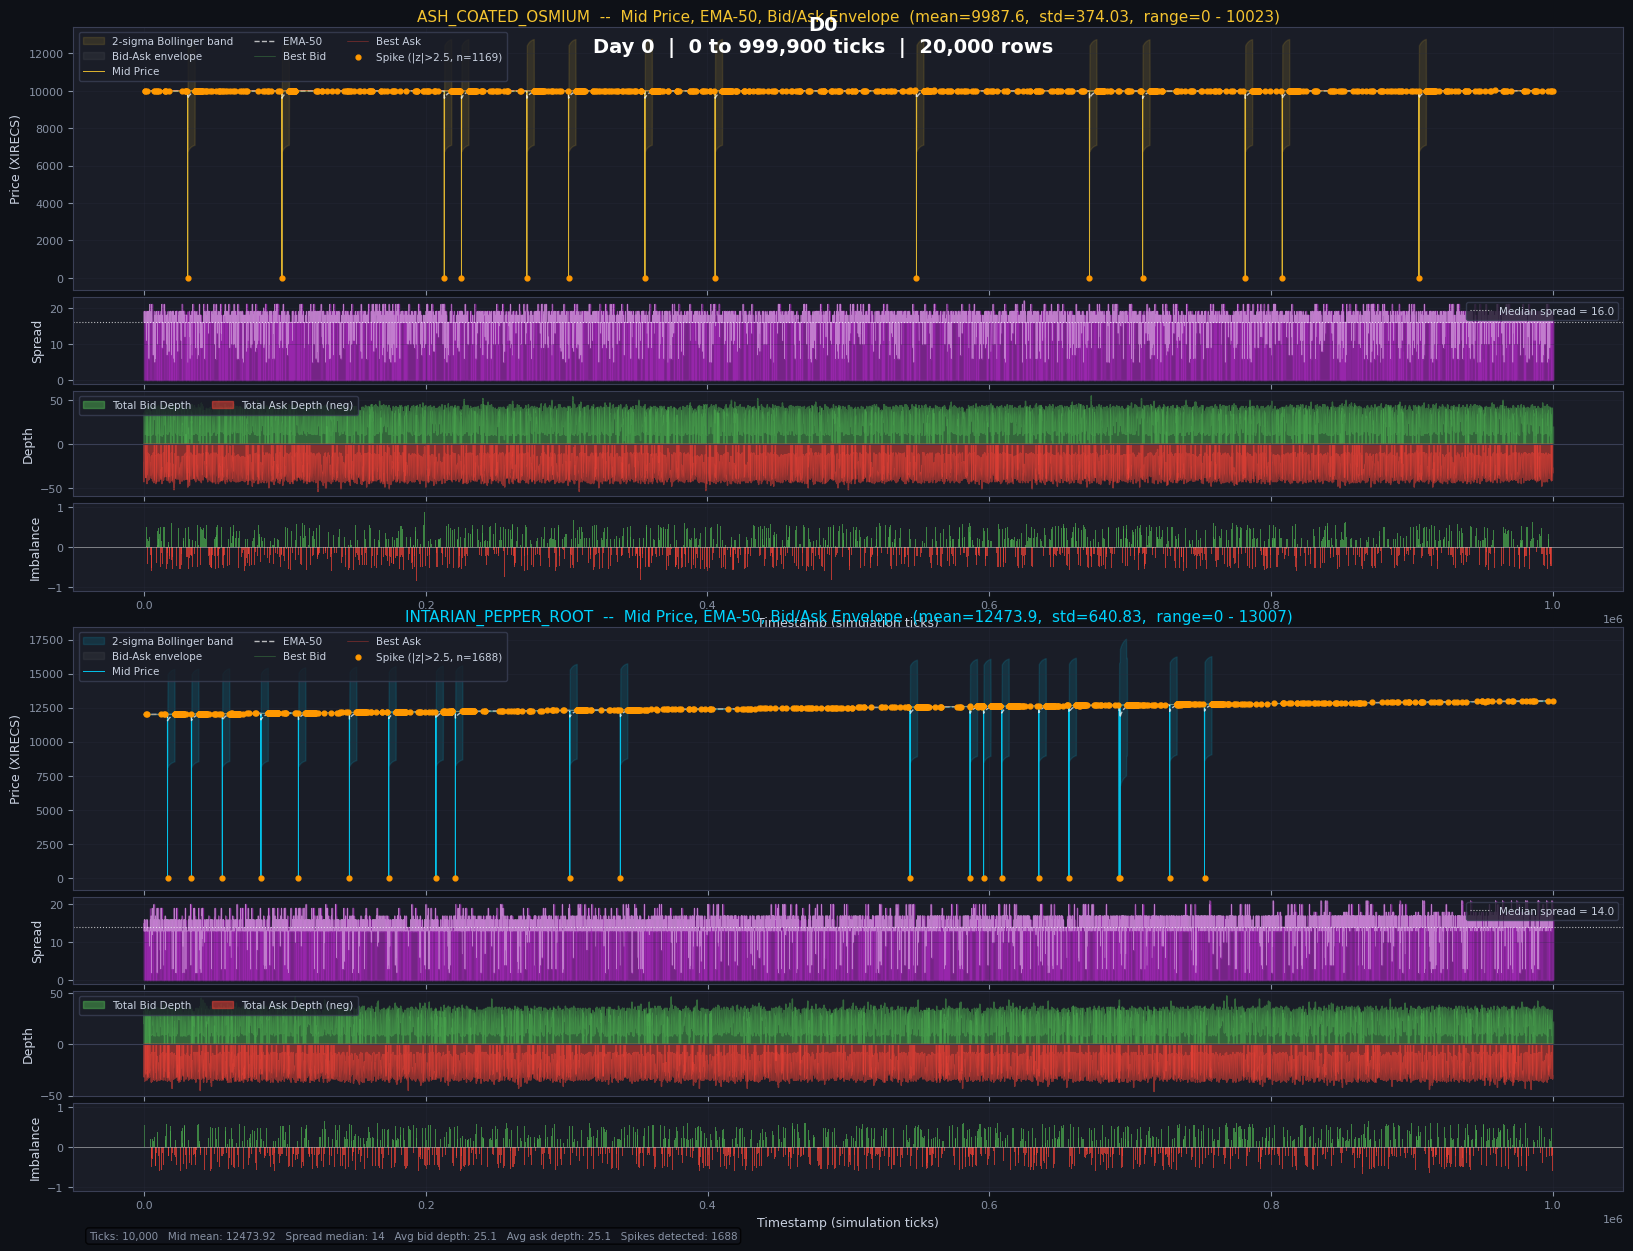

In [18]:
plot_prices_overview(prices_d0, day_label=0,
                     fig_title='D0')

---
### Chart 4: Trades Day -1 — Full Trade-Flow Analysis

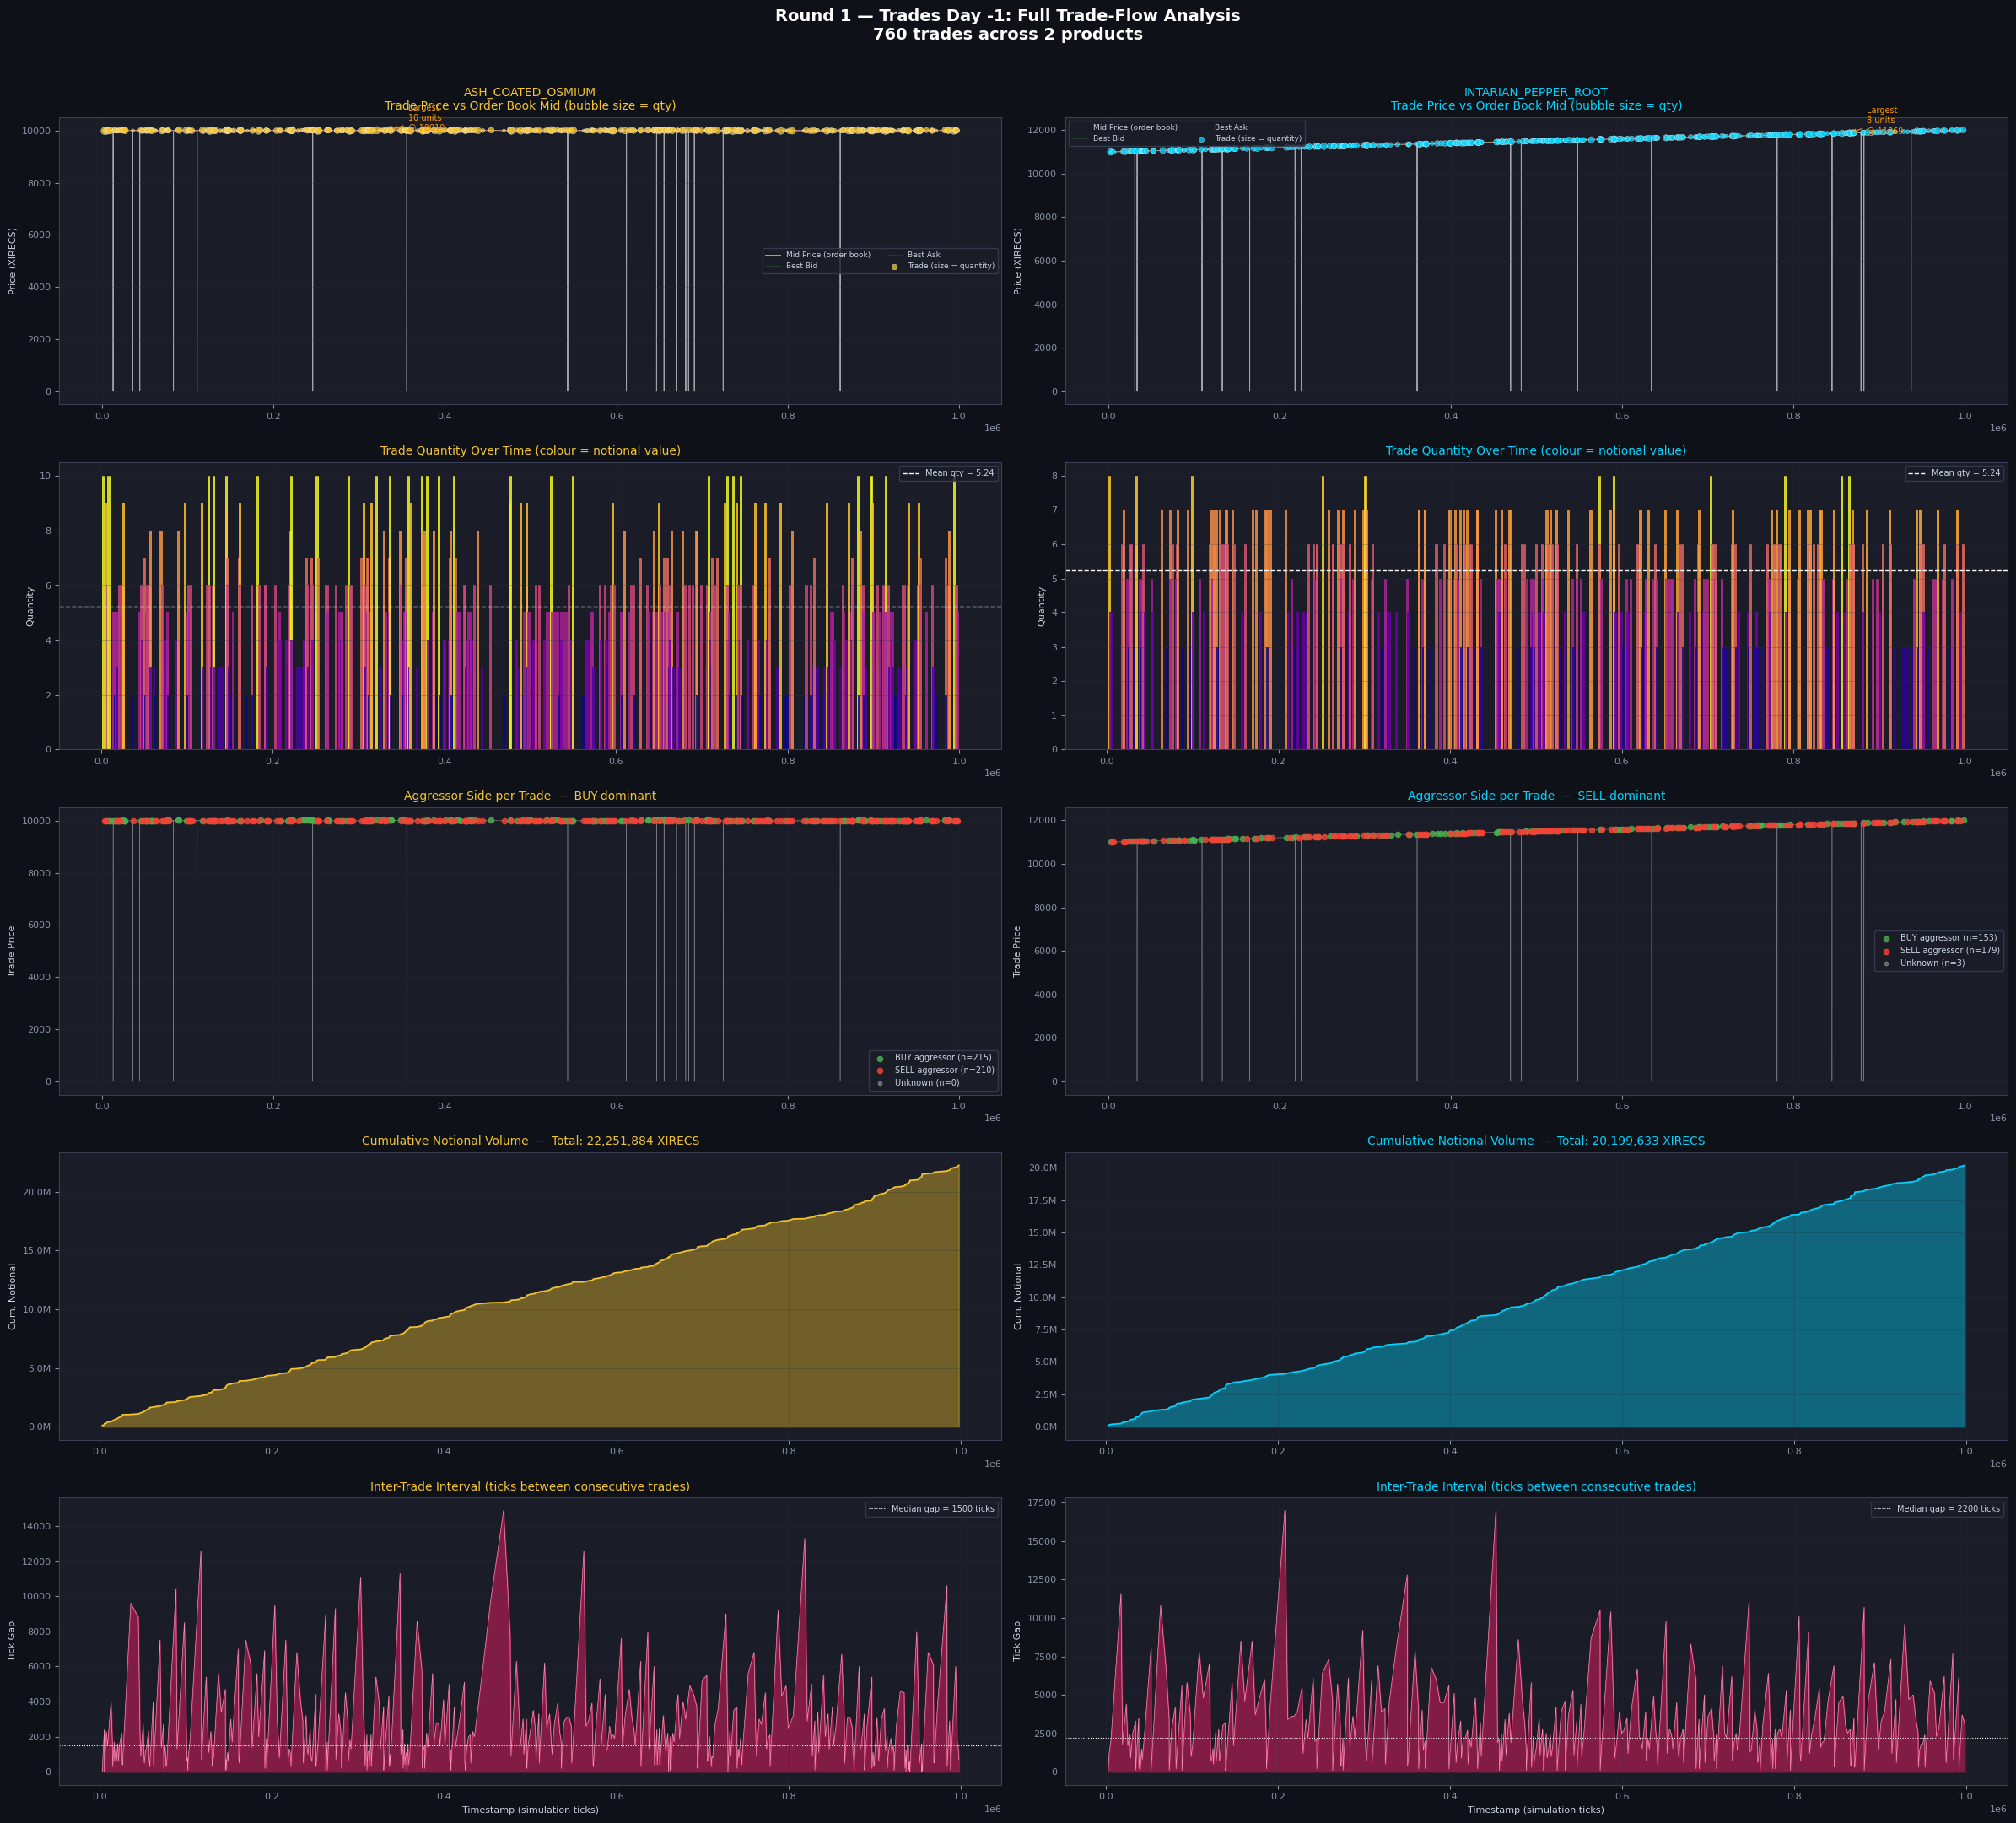

In [19]:
def plot_trades_overview(trades_df, prices_df, day_label):
    """
    Five-panel plot for one trades day:
    Row 1: Trade price vs mid-price per product (scatterplot + line)
    Row 2: Trade quantity over time (bubble-sized by notional)
    Row 3: Aggressor-side (BUY vs SELL) identified from trade price vs book
    Row 4: Cumulative notional volume
    Row 5: Inter-trade interval (time between consecutive trades)
    """
    products = sorted(trades_df['symbol'].unique())
    n_products = len(products)

    # Identify aggressor side: trade at ask = buyer aggressed; trade at bid = seller aggressed
    merged = pd.merge(
        left    = prices_df[prices_df['day'] == day_label],
        right   = trades_df,
        left_on  = ['timestamp', 'product'],
        right_on = ['timestamp', 'symbol'],
        how      = 'inner',
        suffixes = ('_book', '_trade'),
    )
    merged['aggressor'] = np.where(
        np.abs(merged['price'] - merged['ask_price_1']) < 0.01, 'BUY',
        np.where(
            np.abs(merged['price'] - merged['bid_price_1']) < 0.01, 'SELL', 'UNKNOWN'
        )
    )

    palette = {
        products[0]: '#f4c430',
        products[1]: '#00d4ff',
    } if n_products >= 2 else {products[0]: '#f4c430'}

    fig, axes = plt.subplots(
        5, n_products, figsize=(12 * n_products, 22),
        facecolor='#0e1117'
    )
    fig.suptitle(
        f'Round 1 — Trades Day {day_label}: Full Trade-Flow Analysis\n'
        f'{len(trades_df):,} trades across {n_products} products',
        fontsize=14, fontweight='bold', color='white'
    )

    if n_products == 1:
        axes = axes.reshape(-1, 1)

    for col_idx, product in enumerate(products):
        color  = palette.get(product, '#f4c430')
        tdf    = trades_df[trades_df['symbol'] == product].sort_values('timestamp').copy()
        pdf    = prices_df[
            (prices_df['product'] == product) &
            (prices_df['day'] == day_label)
        ].sort_values('timestamp')
        m_prod = merged[merged['symbol'] == product]

        # ---- Row 0: Trade price vs mid price ----
        ax = axes[0, col_idx]
        ax.plot(pdf['timestamp'], pdf['mid_price'],
                color='white', linewidth=0.7, alpha=0.6, label='Mid Price (order book)', zorder=1)
        ax.plot(pdf['timestamp'], pdf['bid_price_1'],
                color='#4caf50', linewidth=0.4, alpha=0.4, label='Best Bid')
        ax.plot(pdf['timestamp'], pdf['ask_price_1'],
                color='#f44336', linewidth=0.4, alpha=0.4, label='Best Ask')
        ax.scatter(tdf['timestamp'], tdf['price'],
                   s=tdf['quantity'] * 4, color=color, alpha=0.75,
                   zorder=3, edgecolors='white', linewidths=0.3,
                   label='Trade (size = quantity)')
        # Annotate largest trade
        if len(tdf) > 0:
            max_row = tdf.loc[tdf['notional'].idxmax()]
            ax.annotate(
                f'Largest\n{max_row["quantity"]:.0f} units\n@ {max_row["price"]:.0f}',
                xy=(max_row['timestamp'], max_row['price']),
                xytext=(max_row['timestamp'] + 20000, max_row['price']),
                fontsize=7, color='#ff9800',
                arrowprops=dict(arrowstyle='->', color='#ff9800', lw=0.8)
            )
        ax.set_title(f'{product}\nTrade Price vs Order Book Mid (bubble size = qty)', fontsize=10, color=color)
        ax.set_ylabel('Price (XIRECS)', fontsize=8)
        ax.legend(fontsize=6.5, ncol=2)
        ax.grid(True, alpha=0.3)

        # ---- Row 1: Trade quantity ----
        ax = axes[1, col_idx]
        norm_notional = (tdf['notional'] - tdf['notional'].min()) / \
                        (tdf['notional'].max() - tdf['notional'].min() + 1)
        bar_colors = plt.cm.plasma(norm_notional.values)
        ax.bar(tdf['timestamp'], tdf['quantity'], width=3000,
               color=bar_colors, alpha=0.85)
        ax.axhline(tdf['quantity'].mean(), color='white', linewidth=1.0, linestyle='--',
                   label=f'Mean qty = {tdf["quantity"].mean():.2f}')
        ax.set_title('Trade Quantity Over Time (colour = notional value)', fontsize=10, color=color)
        ax.set_ylabel('Quantity', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        # ---- Row 2: Aggressor side ----
        ax = axes[2, col_idx]
        buy_trades  = m_prod[m_prod['aggressor'] == 'BUY']
        sell_trades = m_prod[m_prod['aggressor'] == 'SELL']
        unk_trades  = m_prod[m_prod['aggressor'] == 'UNKNOWN']
        ax.scatter(buy_trades['timestamp'],  buy_trades['price'],
                   color='#4caf50', s=20, alpha=0.8, label=f'BUY aggressor (n={len(buy_trades)})',  zorder=3)
        ax.scatter(sell_trades['timestamp'], sell_trades['price'],
                   color='#f44336', s=20, alpha=0.8, label=f'SELL aggressor (n={len(sell_trades)})', zorder=3)
        ax.scatter(unk_trades['timestamp'],  unk_trades['price'],
                   color='#aaaaaa', s=10, alpha=0.5, label=f'Unknown (n={len(unk_trades)})',         zorder=2)
        ax.plot(pdf['timestamp'], pdf['mid_price'], color='white', linewidth=0.4, alpha=0.4)
        net_side = 'BUY-dominant' if len(buy_trades) > len(sell_trades) else 'SELL-dominant'
        ax.set_title(f'Aggressor Side per Trade  --  {net_side}', fontsize=10, color=color)
        ax.set_ylabel('Trade Price', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        # ---- Row 3: Cumulative notional ----
        ax = axes[3, col_idx]
        tdf['cum_notional'] = tdf['notional'].cumsum()
        ax.fill_between(tdf['timestamp'], tdf['cum_notional'], alpha=0.4, color=color)
        ax.plot(tdf['timestamp'], tdf['cum_notional'], color=color, linewidth=1.2)
        total_notional = tdf['notional'].sum()
        ax.set_title(
            f'Cumulative Notional Volume  --  Total: {total_notional:,.0f} XIRECS',
            fontsize=10, color=color
        )
        ax.set_ylabel('Cum. Notional', fontsize=8)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.grid(True, alpha=0.3)

        # ---- Row 4: Inter-trade interval ----
        ax = axes[4, col_idx]
        tdf['interval'] = tdf['timestamp'].diff().fillna(0)
        ax.fill_between(tdf['timestamp'], tdf['interval'], alpha=0.5, color='#e91e63')
        ax.plot(tdf['timestamp'], tdf['interval'], color='#f48fb1', linewidth=0.5)
        ax.axhline(tdf['interval'].median(), color='white', linewidth=0.8, linestyle=':',
                   label=f'Median gap = {tdf["interval"].median():.0f} ticks')
        ax.set_title('Inter-Trade Interval (ticks between consecutive trades)', fontsize=10, color=color)
        ax.set_ylabel('Tick Gap', fontsize=8)
        ax.set_xlabel('Timestamp (simulation ticks)', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


plot_trades_overview(trades_dm1, prices_dm1, day_label=-1)

---
### Chart 5: Cross-Day Comparison — Mid Price Trajectory for Both Products

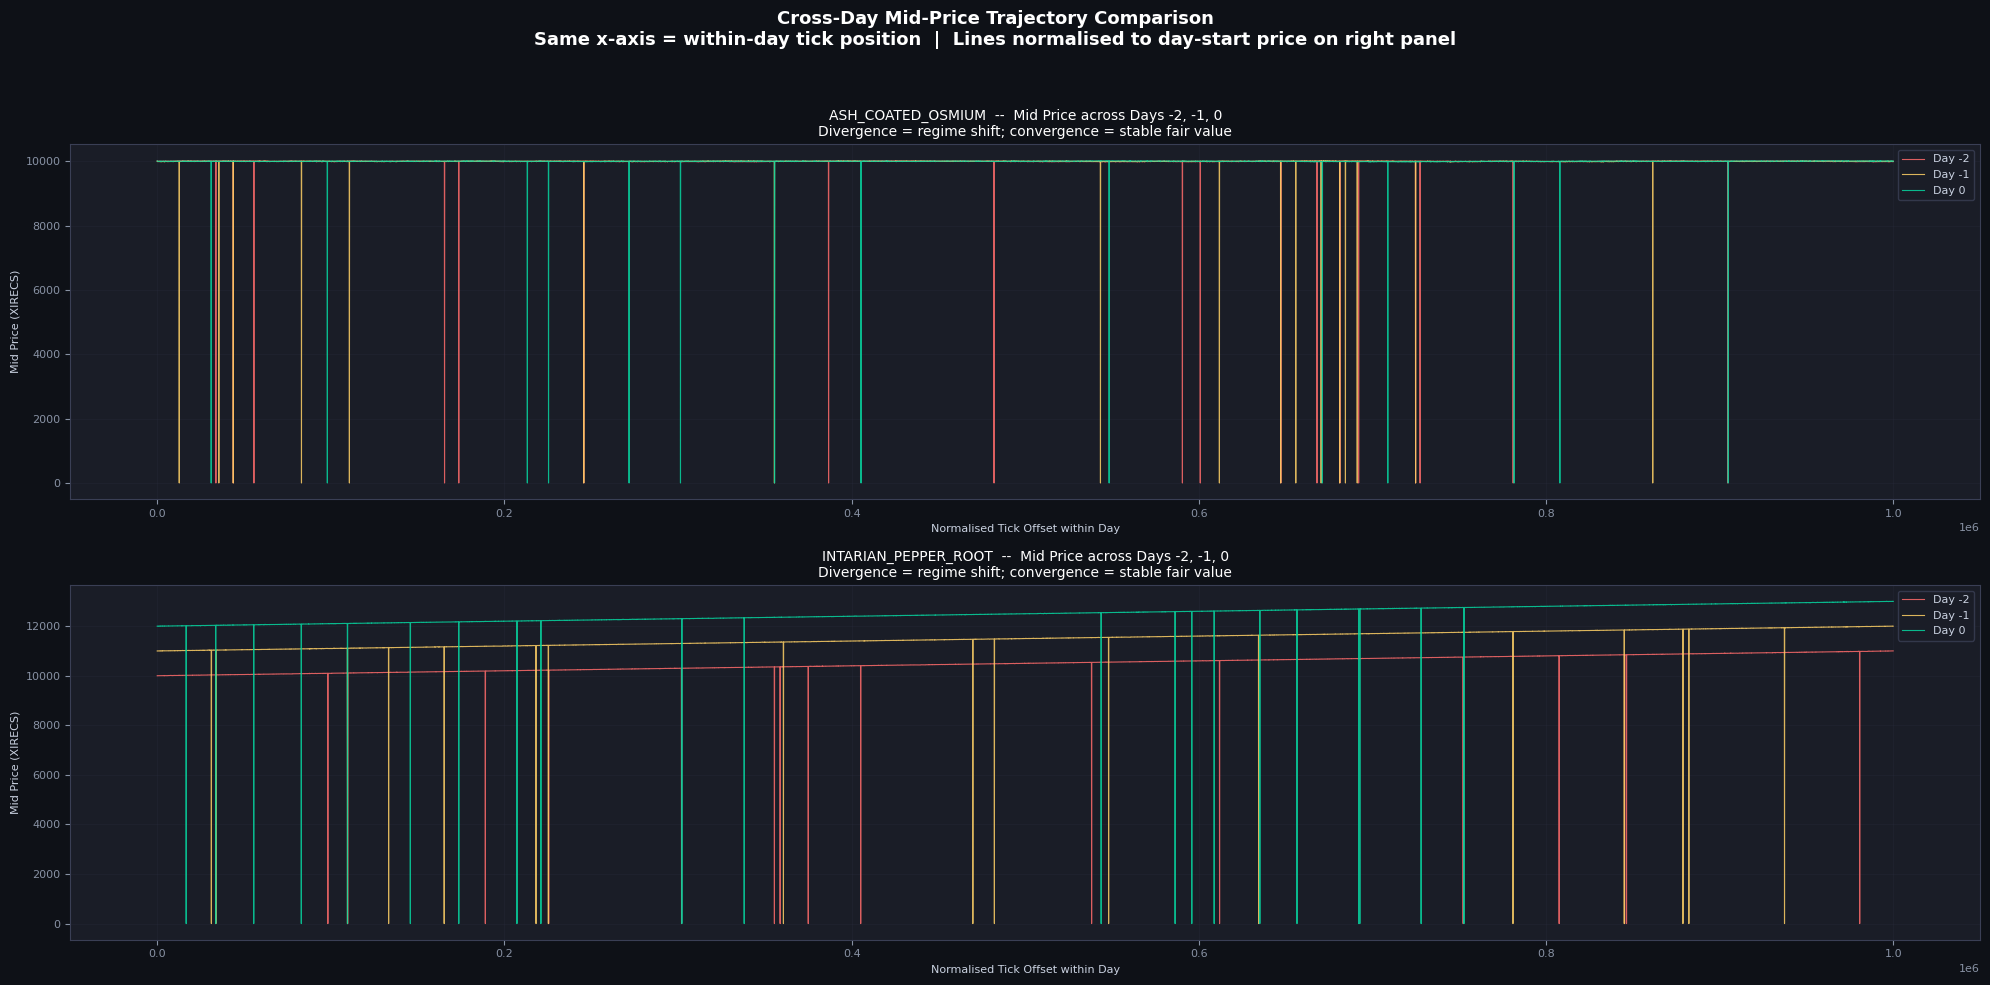

In [20]:
def plot_cross_day_comparison(prices_dict):
    """
    Overlay mid-price trajectories across all three days for each product.
    Useful for spotting day-over-day regime changes and price level drift.
    """
    products = sorted(prices_all['product'].unique())
    day_colors = {-2: '#ff6b6b', -1: '#ffd166', 0: '#06d6a0'}
    fig, axes = plt.subplots(len(products), 1, figsize=(20, 5 * len(products)),
                             facecolor='#0e1117')
    if len(products) == 1:
        axes = [axes]

    fig.suptitle(
        'Cross-Day Mid-Price Trajectory Comparison\n'
        'Same x-axis = within-day tick position  |  Lines normalised to day-start price on right panel',
        fontsize=13, fontweight='bold', color='white'
    )

    for ax, product in zip(axes, products):
        for day_val, (label, df) in zip(
            sorted(prices_dict.keys()),
            [(k, v) for k, v in sorted(prices_dict.items())]
        ):
            pdf = df[df['product'] == product].sort_values('timestamp').copy()
            if len(pdf) == 0:
                continue
            c = day_colors.get(day_val, '#ffffff')
            # Normalise timestamp to 0-based within day
            ts_norm = pdf['timestamp'] - pdf['timestamp'].min()
            ax.plot(ts_norm, pdf['mid_price'], color=c, linewidth=0.8,
                    alpha=0.85, label=f'Day {day_val}')

        ax.set_title(
            f'{product}  --  Mid Price across Days -2, -1, 0\n'
            f'Divergence = regime shift; convergence = stable fair value',
            fontsize=10, color='white'
        )
        ax.set_xlabel('Normalised Tick Offset within Day', fontsize=8)
        ax.set_ylabel('Mid Price (XIRECS)', fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_cross_day_comparison({
    -2: prices_dm2,
    -1: prices_dm1,
     0: prices_d0,
})

---
### Chart 6: Volatility & Spread Regime Analysis

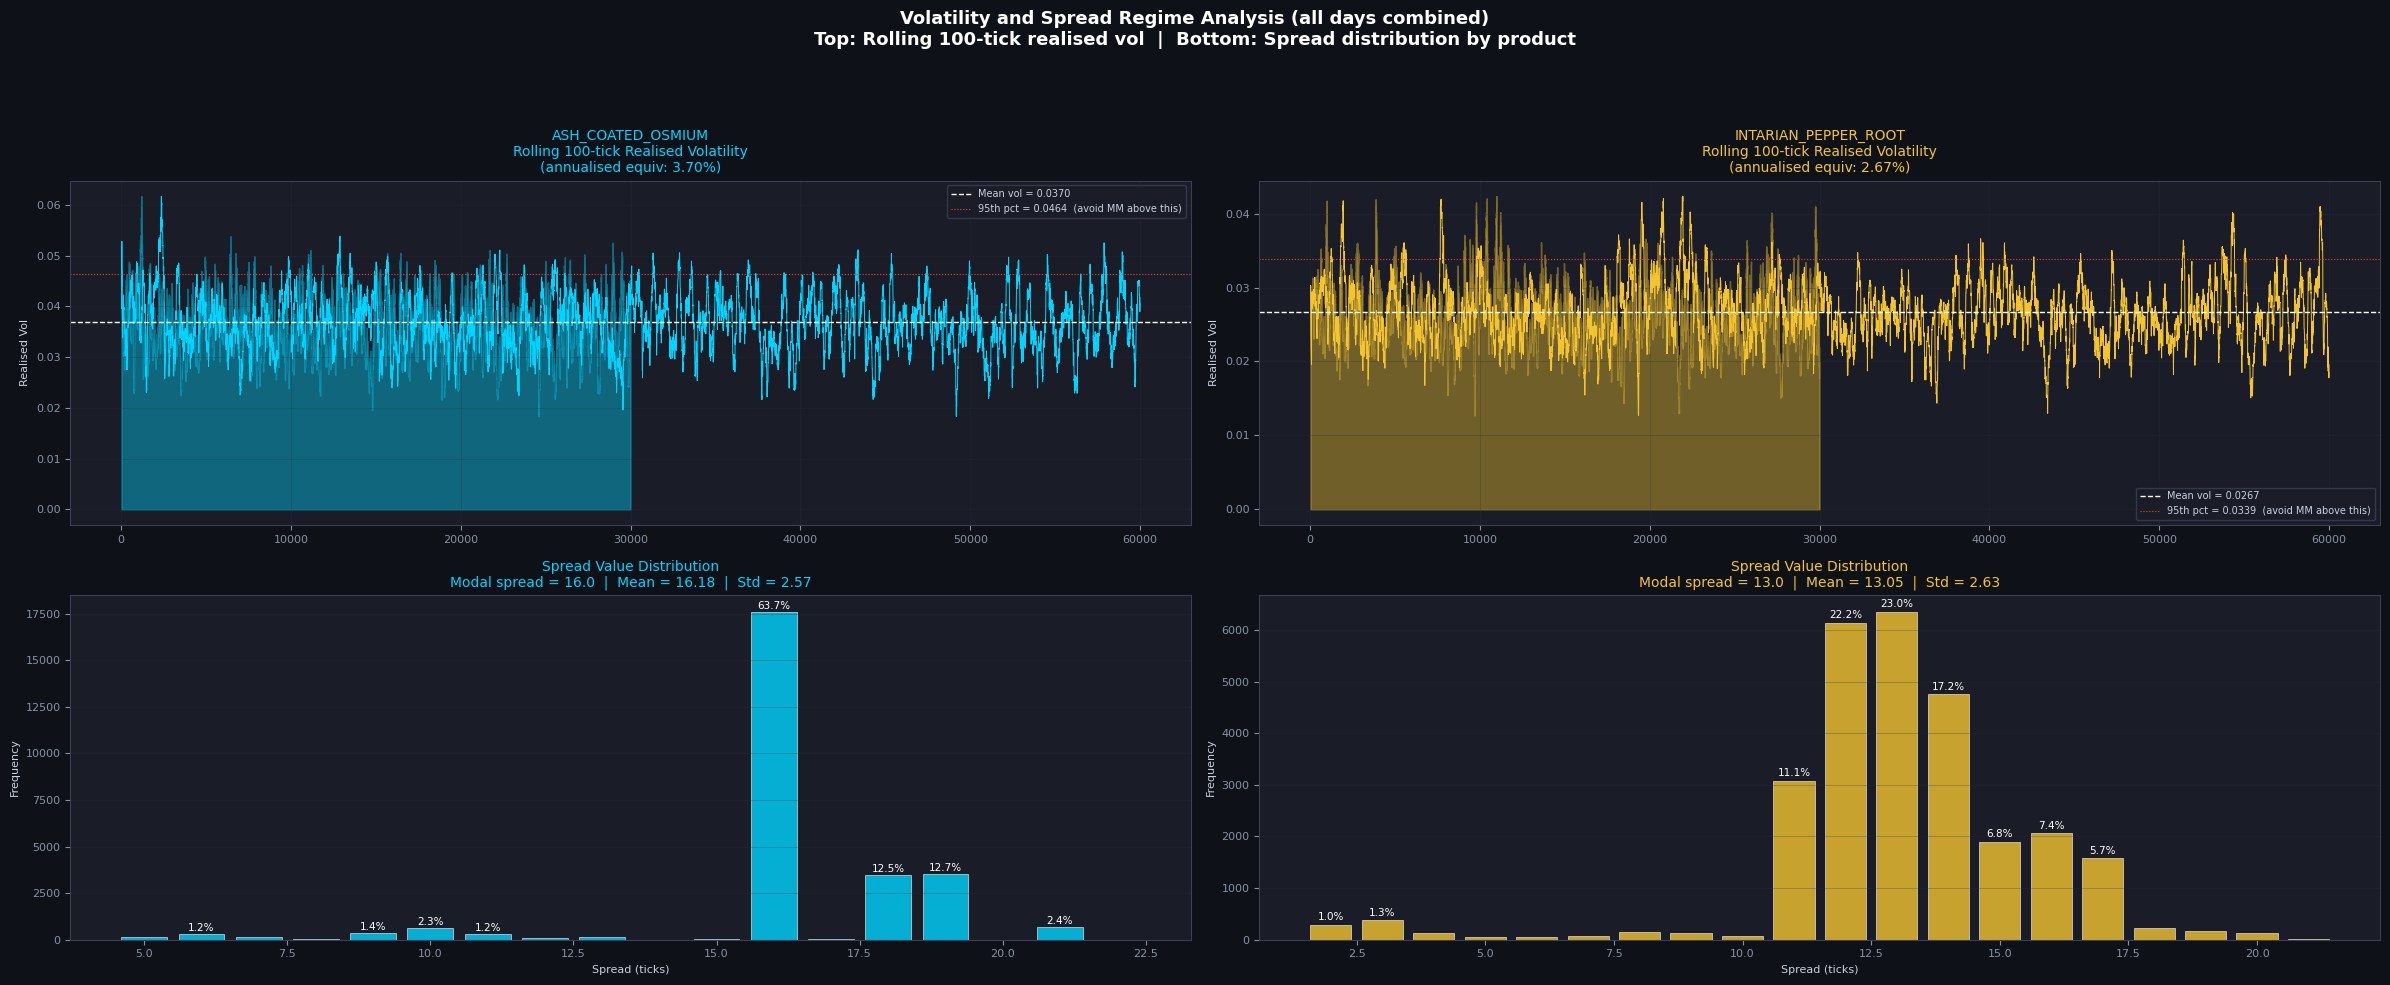

In [21]:
def plot_volatility_analysis(prices_df):
    """
    Rolling 100-tick realised volatility and spread regime analysis.
    Key for parameterising the mean-reversion Z-score threshold for ASH_COATED_OSMIUM
    and calibrating the market-making spread for INTARIAN_PEPPER_ROOT.
    """
    products = sorted(prices_df['product'].unique())
    palette  = {'INTARIAN_PEPPER_ROOT': '#f4c430', 'ASH_COATED_OSMIUM': '#00d4ff'}

    fig, axes = plt.subplots(2, len(products), figsize=(12 * len(products), 10),
                             facecolor='#0e1117')
    fig.suptitle(
        'Volatility and Spread Regime Analysis (all days combined)\n'
        'Top: Rolling 100-tick realised vol  |  Bottom: Spread distribution by product',
        fontsize=13, fontweight='bold', color='white'
    )

    for col, product in enumerate(products):
        c   = palette.get(product, '#f4c430')
        pdf = prices_df[prices_df['product'] == product].sort_values(
                  ['day', 'timestamp']).copy()
        pdf['log_ret']   = np.log(pdf['mid_price'] / pdf['mid_price'].shift(1))
        pdf['realised_vol'] = pdf['log_ret'].rolling(100, min_periods=10).std() * np.sqrt(10000)

        # Row 0: Rolling vol
        ax = axes[0, col] if len(products) > 1 else axes[0]
        ax.fill_between(range(len(pdf)), pdf['realised_vol'], alpha=0.4, color=c)
        ax.plot(pdf['realised_vol'], color=c, linewidth=0.7)
        ax.axhline(pdf['realised_vol'].mean(), color='white', linewidth=1.0,
                   linestyle='--', label=f'Mean vol = {pdf["realised_vol"].mean():.4f}')
        # High-vol regime annotation
        vol_95 = pdf['realised_vol'].quantile(0.95)
        ax.axhline(vol_95, color='#f44336', linewidth=0.8, linestyle=':',
                   label=f'95th pct = {vol_95:.4f}  (avoid MM above this)')
        ax.set_title(
            f'{product}\nRolling 100-tick Realised Volatility\n'
            f'(annualised equiv: {pdf["realised_vol"].mean()*100:.2f}%)',
            fontsize=10, color=c
        )
        ax.set_ylabel('Realised Vol', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        # Row 1: Spread distribution
        ax = axes[1, col] if len(products) > 1 else axes[1]
        spread_vals = pdf['spread'].dropna()
        unique_spreads = sorted(spread_vals.unique())
        counts = [spread_vals.value_counts().get(s, 0) for s in unique_spreads]
        bars = ax.bar(unique_spreads, counts, color=c, alpha=0.8, edgecolor='white',
                      linewidth=0.5)
        # Annotate each bar with percentage
        total = sum(counts)
        for bar, count in zip(bars, counts):
            pct = count / total * 100
            if pct > 1.0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.002,
                        f'{pct:.1f}%', ha='center', va='bottom', fontsize=7.5, color='white')
        ax.set_title(
            f'Spread Value Distribution\n'
            f'Modal spread = {spread_vals.mode()[0]}  |  '
            f'Mean = {spread_vals.mean():.2f}  |  '
            f'Std = {spread_vals.std():.2f}',
            fontsize=10, color=c
        )
        ax.set_xlabel('Spread (ticks)', fontsize=8)
        ax.set_ylabel('Frequency', fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


plot_volatility_analysis(prices_all)

---
## 8. Microstructure Tables: Order Book at a Specific Timestamp

In [22]:
# Inspect the full order book at any timestamp -- change INSPECT_TS to explore
INSPECT_TS  = 4200
INSPECT_DAY = -1

snapshot = prices_dm1[
    (prices_dm1['timestamp'] == INSPECT_TS) &
    (prices_dm1['day'] == INSPECT_DAY)
]

print(f'Order book at timestamp {INSPECT_TS:,}  (Day {INSPECT_DAY})')
display(snapshot)

print()
for _, row in snapshot.iterrows():
    product = row['product']
    print(f'{product}')
    print(f'  BID side:  L1 = {row["bid_price_1"]:.0f} x {row["bid_volume_1"]:.0f}', end='')
    if pd.notna(row['bid_price_2']):
        print(f'  |  L2 = {row["bid_price_2"]:.0f} x {row["bid_volume_2"]:.0f}', end='')
    if pd.notna(row['bid_price_3']):
        print(f'  |  L3 = {row["bid_price_3"]:.0f} x {row["bid_volume_3"]:.0f}', end='')
    print()
    print(f'  ASK side:  L1 = {row["ask_price_1"]:.0f} x {row["ask_volume_1"]:.0f}', end='')
    if pd.notna(row['ask_price_2']):
        print(f'  |  L2 = {row["ask_price_2"]:.0f} x {row["ask_volume_2"]:.0f}', end='')
    if pd.notna(row['ask_price_3']):
        print(f'  |  L3 = {row["ask_price_3"]:.0f} x {row["ask_volume_3"]:.0f}', end='')
    print()
    print(f'  Mid price: {row["mid_price"]:.1f}  |  Spread: {row["spread"]:.0f}  |  '
          f'Bid depth: {row["total_bid_depth"]:.0f}  |  Ask depth: {row["total_ask_depth"]:.0f}  |  '
          f'Imbalance: {row["book_imbalance"]:.3f}')
    print()

Order book at timestamp 4,200  (Day -1)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,total_bid_depth,total_ask_depth,book_imbalance
84,-1,4200,INTARIAN_PEPPER_ROOT,10995.00,25.00,NaN,NaN,NaN,NaN,11010.00,11.00,NaN,NaN,NaN,NaN,11002.50,0.00,15.00,25.00,11.00,0.39
85,-1,4200,ASH_COATED_OSMIUM,9983.00,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9983.00,0.00,NaN,24.00,NaN,NaN



INTARIAN_PEPPER_ROOT
  BID side:  L1 = 10995 x 25
  ASK side:  L1 = 11010 x 11
  Mid price: 11002.5  |  Spread: 15  |  Bid depth: 25  |  Ask depth: 11  |  Imbalance: 0.389

ASH_COATED_OSMIUM
  BID side:  L1 = 9983 x 24
  ASK side:  L1 = nan x nan
  Mid price: 9983.0  |  Spread: nan  |  Bid depth: 24  |  Ask depth: nan  |  Imbalance: nan



---
## 9. Quick-Access Slice Variables

In [23]:
# Detect actual product names dynamically
PRODUCT_A = [p for p in PRODUCTS if 'PEPPER' in p or 'EMERALD' in p][0] if PRODUCTS else PRODUCTS[0]
PRODUCT_B = [p for p in PRODUCTS if 'OSMIUM' in p or 'TOMATO' in p][0] if len(PRODUCTS) > 1 else PRODUCTS[-1]

# --- Product slices (all days) ---
pepper_root  = prices_all[prices_all['product'] == PRODUCT_A].copy()
ash_osmium   = prices_all[prices_all['product'] == PRODUCT_B].copy()

# --- Per-day slices ---
pepper_dm2 = prices_dm2[prices_dm2['product'] == PRODUCT_A].copy()
pepper_dm1 = prices_dm1[prices_dm1['product'] == PRODUCT_A].copy()
pepper_d0  = prices_d0 [prices_d0['product']  == PRODUCT_A].copy()
osmium_dm2 = prices_dm2[prices_dm2['product'] == PRODUCT_B].copy()
osmium_dm1 = prices_dm1[prices_dm1['product'] == PRODUCT_B].copy()
osmium_d0  = prices_d0 [prices_d0['product']  == PRODUCT_B].copy()

# --- Spread / book structure filters ---
pepper_narrow_spread = pepper_root[pepper_root['spread'] <= pepper_root['spread'].quantile(0.05)]
osmium_narrow_spread = ash_osmium [ash_osmium['spread']  <= ash_osmium ['spread'].quantile(0.05)]
has_l3_book          = prices_all[prices_all['bid_price_3'].notna()]

# --- Trade slices ---
pepper_trades = trades_dm1[trades_dm1['symbol'] == PRODUCT_A]
osmium_trades = trades_dm1[trades_dm1['symbol'] == PRODUCT_B]

print('Slice variables created:')
print(f'  pepper_root         {str(pepper_root.shape):15s}  -- {PRODUCT_A} prices, all days')
print(f'  ash_osmium          {str(ash_osmium.shape):15s}  -- {PRODUCT_B} prices, all days')
print(f'  pepper_dm2          {str(pepper_dm2.shape):15s}  -- {PRODUCT_A} Day -2')
print(f'  pepper_dm1          {str(pepper_dm1.shape):15s}  -- {PRODUCT_A} Day -1')
print(f'  pepper_d0           {str(pepper_d0.shape):15s}  -- {PRODUCT_A} Day  0')
print(f'  osmium_dm2          {str(osmium_dm2.shape):15s}  -- {PRODUCT_B} Day -2')
print(f'  osmium_dm1          {str(osmium_dm1.shape):15s}  -- {PRODUCT_B} Day -1')
print(f'  osmium_d0           {str(osmium_d0.shape):15s}  -- {PRODUCT_B} Day  0')
print(f'  pepper_narrow_spread{str(pepper_narrow_spread.shape):15s}  -- {PRODUCT_A} ticks at 5th pct spread')
print(f'  osmium_narrow_spread{str(osmium_narrow_spread.shape):15s}  -- {PRODUCT_B} ticks at 5th pct spread')
print(f'  has_l3_book         {str(has_l3_book.shape):15s}  -- Any product with 3-level order book')
print(f'  pepper_trades       {str(pepper_trades.shape):15s}  -- {PRODUCT_A} trades (Day -1)')
print(f'  osmium_trades       {str(osmium_trades.shape):15s}  -- {PRODUCT_B} trades (Day -1)')

Slice variables created:
  pepper_root         (30000, 21)      -- INTARIAN_PEPPER_ROOT prices, all days
  ash_osmium          (30000, 21)      -- ASH_COATED_OSMIUM prices, all days
  pepper_dm2          (10000, 21)      -- INTARIAN_PEPPER_ROOT Day -2
  pepper_dm1          (10000, 21)      -- INTARIAN_PEPPER_ROOT Day -1
  pepper_d0           (10000, 21)      -- INTARIAN_PEPPER_ROOT Day  0
  osmium_dm2          (10000, 21)      -- ASH_COATED_OSMIUM Day -2
  osmium_dm1          (10000, 21)      -- ASH_COATED_OSMIUM Day -1
  osmium_d0           (10000, 21)      -- ASH_COATED_OSMIUM Day  0
  pepper_narrow_spread(4370, 21)       -- INTARIAN_PEPPER_ROOT ticks at 5th pct spread
  osmium_narrow_spread(1722, 21)       -- ASH_COATED_OSMIUM ticks at 5th pct spread
  has_l3_book         (1224, 21)       -- Any product with 3-level order book
  pepper_trades       (335, 9)         -- INTARIAN_PEPPER_ROOT trades (Day -1)
  osmium_trades       (425, 9)         -- ASH_COATED_OSMIUM trades (Day -1)


---
## 10. Strategy Signal Sanity Checks

Quick checks that confirm the expected behaviour before building the trader.

In [24]:
print('=== INTARIAN_PEPPER_ROOT: Fair Value Stability Check ===')
pr = pepper_root['mid_price']
print(f'  Mean mid price : {pr.mean():.4f}')
print(f'  Std dev        : {pr.std():.4f}')
print(f'  Price range    : {pr.min():.0f}  to  {pr.max():.0f}')
print(f'  CoV (std/mean) : {pr.std()/pr.mean():.6f}  <- should be near 0 for stable asset')
print()

# Autocorrelation of mid-price returns (checks for mean reversion structure)
pr_returns = pr.diff().dropna()
autocorr_lag1  = pr_returns.autocorr(lag=1)
autocorr_lag5  = pr_returns.autocorr(lag=5)
autocorr_lag20 = pr_returns.autocorr(lag=20)
print(f'  Return autocorr lag-1  : {autocorr_lag1:.4f}  <- negative = mean reverting')
print(f'  Return autocorr lag-5  : {autocorr_lag5:.4f}')
print(f'  Return autocorr lag-20 : {autocorr_lag20:.4f}')
print()

print('=== ASH_COATED_OSMIUM: Volatility and Spike Check ===')
ao = ash_osmium['mid_price']
print(f'  Mean mid price : {ao.mean():.4f}')
print(f'  Std dev        : {ao.std():.4f}')
print(f'  Price range    : {ao.min():.0f}  to  {ao.max():.0f}')
print(f'  CoV (std/mean) : {ao.std()/ao.mean():.6f}')
ao_returns = ao.diff().dropna()
ao_z = (ao_returns - ao_returns.mean()) / ao_returns.std()
n_spikes = (ao_z.abs() > 2.5).sum()
print(f'  |Z-score| > 2.5 ticks : {n_spikes}  ({n_spikes/len(ao)*100:.2f}%)  <- candidates for jump detection')
print()

print('=== SPREAD CAPTURE POTENTIAL (INTARIAN_PEPPER_ROOT) ===')
modal_spread = pepper_root['spread'].mode()[0]
freq_modal   = (pepper_root['spread'] == modal_spread).mean() * 100
print(f'  Modal spread: {modal_spread}  (appears {freq_modal:.1f}% of ticks)')
print(f'  If you capture half-spread both sides: {modal_spread/2:.1f} XIRECS per round trip')
print(f'  Position limit: 80 units  ->  max per-side capture: {80 * modal_spread/2:.0f} XIRECS per fill')

=== INTARIAN_PEPPER_ROOT: Fair Value Stability Check ===
  Mean mid price : 11479.1887
  Std dev        : 993.1848
  Price range    : 0  to  13007
  CoV (std/mean) : 0.086520  <- should be near 0 for stable asset

  Return autocorr lag-1  : -0.5001  <- negative = mean reverting
  Return autocorr lag-5  : -0.0112
  Return autocorr lag-20 : 0.0000

=== ASH_COATED_OSMIUM: Volatility and Spike Check ===
  Mean mid price : 9983.8706
  Std dev        : 403.8654
  Price range    : 0  to  10023
  CoV (std/mean) : 0.040452
  |Z-score| > 2.5 ticks : 98  (0.33%)  <- candidates for jump detection

=== SPREAD CAPTURE POTENTIAL (INTARIAN_PEPPER_ROOT) ===
  Modal spread: 13.0  (appears 21.2% of ticks)
  If you capture half-spread both sides: 6.5 XIRECS per round trip
  Position limit: 80 units  ->  max per-side capture: 520 XIRECS per fill


In [25]:
# Final summary printout
print('=== DATA LOAD SUMMARY ===')
print()
print(f'Three price datasets loaded:  {prices_dm2.shape[0]:,} + {prices_dm1.shape[0]:,} + {prices_d0.shape[0]:,} rows')
print(f'One trades dataset loaded:    {trades_dm1.shape[0]:,} rows')
print(f'Products detected:            {PRODUCTS}')
print(f'Position limits (per rules):  80 for each product')
print()
print('KEY OBSERVATIONS:')
for product in PRODUCTS:
    pdf = prices_all[prices_all['product'] == product]
    print(f'  {product}:')
    print(f'    Mid price range  :  {pdf["mid_price"].min():.0f}  --  {pdf["mid_price"].max():.0f}')
    print(f'    Median spread    :  {pdf["spread"].median():.0f}')
    print(f'    Mid price std    :  {pdf["mid_price"].std():.2f}')
    strategy = (
        'MARKET MAKING (stable fair value, low std)'
        if pdf['mid_price'].std() < 5
        else 'MEAN REVERSION / JUMP DETECTION (volatile, high std)'
    )
    print(f'    Suggested strategy:  {strategy}')
    print()

=== DATA LOAD SUMMARY ===

Three price datasets loaded:  20,000 + 20,000 + 20,000 rows
One trades dataset loaded:    760 rows
Products detected:            ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
Position limits (per rules):  80 for each product

KEY OBSERVATIONS:
  ASH_COATED_OSMIUM:
    Mid price range  :  0  --  10023
    Median spread    :  16
    Mid price std    :  403.87
    Suggested strategy:  MEAN REVERSION / JUMP DETECTION (volatile, high std)

  INTARIAN_PEPPER_ROOT:
    Mid price range  :  0  --  13007
    Median spread    :  13
    Mid price std    :  993.18
    Suggested strategy:  MEAN REVERSION / JUMP DETECTION (volatile, high std)

